<a href="https://colab.research.google.com/github/esshak-bu/Time-Variance-Authority/blob/main/TIMEVARIANCEAUTHORITY_Hackathon_SP2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- 1. Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- 2. Create the target folder inside the user's Drive ---
import os

target_dir = "/content/drive/MyDrive/hackathon-sp2026"
os.makedirs(target_dir, exist_ok=True)
print("Saving files to:", target_dir)


Saving files to: /content/drive/MyDrive/hackathon-sp2026


In [ ]:
# --- 3. Install gdown and download the shared file ---
!pip install -q gdown

FILE_ID = "1Om9a35_7NoJ_lGjauU7miVxXMj76Hl6u"
!gdown --id $FILE_ID -O "{target_dir}/shared_file"

print("Download complete!")
print("File saved at:", os.path.join(target_dir, "shared_file"))


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Om9a35_7NoJ_lGjauU7miVxXMj76Hl6u
From (redirected): https://drive.google.com/uc?id=1Om9a35_7NoJ_lGjauU7miVxXMj76Hl6u&confirm=t&uuid=ed32fecf-9282-447d-aca2-aa22341732bb
To: /content/drive/MyDrive/hackathon-sp2026/shared_file
100% 480M/480M [00:03<00:00, 127MB/s]
Download complete!
File saved at: /content/drive/MyDrive/hackathon-sp2026/shared_file


In [ ]:
import polars as pl
import os

# Path where gdown saved the file
target_dir = "/content/drive/MyDrive/hackathon-sp2026"
file_path = os.path.join(target_dir, "shared_file")   # rename if needed

file_path


'/content/drive/MyDrive/hackathon-sp2026/shared_file'

In [ ]:
import pandas as pd
df = pd.read_csv(file_path)
df.head(10)


/tmp/ipykernel_10638/899178759.py:2: DtypeWarning: Columns (1,17,19,21,22,29,30,31,34,35,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,paper,subj_idx,subj_ident,session,sess_ident,trial_idx,ss_value,ss_time,ll_value,ll_time,...,time_pressure,time_pressure_cont,subj_excl_criteria,trial_excl_criteria,missing_trials_absolute,missing_trials_relative,online_study,rt_in_full_seconds,rt_data_analyzed,comments
0,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,1.0,400000.0,1.0,404000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
1,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,2.0,400000.0,1.0,408000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
2,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,3.0,400000.0,1.0,420000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
3,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,4.0,400000.0,1.0,440000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
4,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,5.0,400000.0,1.0,500000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
5,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,6.0,400000.0,1.0,560000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
6,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,7.0,400000.0,1.0,680000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
7,Alonso-Diaz_2022,G1S1,001_0001,1,001_0001_1,8.0,400000.0,1.0,800000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
8,Alonso-Diaz_2022,G1S10,001_0002,1,001_0002_1,1.0,400000.0,1.0,404000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...
9,Alonso-Diaz_2022,G1S10,001_0002,1,001_0002_1,2.0,400000.0,1.0,408000.0,182.5,...,0,NaN,NaN,NaN,0,0.0,0,0,0,Subject number does not match paper; Some subj...


In [ ]:
trial_curve = df_clean.groupby('trial_idx')['rt'].mean()

trial_curve.plot(figsize=(8,4))
plt.title("RT over trial index")
plt.ylabel("Mean RT (s)")
plt.show()


NameError: name 'df_clean' is not defined

**Exploratory Data Analysis:**
To understand the structure and quality of the dataset, we will explore it using panda functions.

## Dataset Variables (from Paper)

### Identifiers
- **paper**: Dataset key  
- **subj_idx**: Subject index or identifier  
- **subj_ident**: Unique subject identifier across entire dataset (use for subject-level analysis)  
- **session**: Session index (1 if only one session)  
- **sess_ident**: Unique session identifier across dataset  
- **trial_idx**: Trial index (order of trials; NA if unavailable)  

### Choice & Timing Variables
- **ss_value**: Reward value of smaller-sooner option  
- **ss_time**: Delay of smaller-sooner option (days)  
- **ll_value**: Reward value of larger-later option  
- **ll_time**: Delay of larger-later option (days)  
- **choice**: Selected option (SS = 0, LL = 1)  
- **rt**: Response time (seconds)  

### Exclusion Indicators
- **subj_excl**: Subject exclusion flag (FALSE = keep, TRUE = exclude)  
- **subj_excl_ind**: Reason for subject exclusion (NA if none)  
- **trial_excl**: Trial exclusion flag (FALSE = keep, TRUE = exclude)  
- **trial_excl_ind**: Reason for trial exclusion (NA if none)  

### Subject Information
- **age**: Subject age (NA if unavailable)  
- **additional_conditions**: Special subject conditions (not exclusion-related)  

### Dataset Structure
- **subset**: Maps data to specific dataset entries  
- **subset_label**: Description of subset  

### Publication & Data Source
- **doi_publication**: DOI of article  
- **link_data**: Link to dataset (if available)  
- **doi_data**: DOI of dataset (if available)  

### Study Context
- **country**: Country of experiment or participants  
- **currency**: Currency used for rewards  
- **time_unit**: Time unit used in original data  
- **procedure**: Trial construction method  
- **incentivization**: Incentive method  
- **presentation_of_information**: How attributes were presented  

### Experimental Design
- **additional_methods**: Special methods used (if any)  
- **additional_interventions**: Interventions applied (if any)  
- **fixed_attributes**: Attributes fixed throughout study  

### Time Pressure
- **time_pressure**: Response deadline (1 = Yes, 0 = No)  
- **time_pressure_cont**: Length of deadline (seconds)  

### Exclusion Criteria
- **subj_excl_criteria**: Subject exclusion rules  
- **trial_excl_criteria**: Trial exclusion rules  

### Missing Data
- **missing_trials_absolute**: Number of trials with missing key values  
- **missing_trials_relative**: Percentage of trials with missing values  

### Study Characteristics
- **online_study**: Online study (1 = Yes, 0 = No)  
- **rt_in_full_seconds**: RT recorded in full seconds (1 = Yes, 0 = No)  
- **rt_data_analyzed**: RT analyzed in original paper (1 = Yes, 0 = No)  

### Notes
- **comments**: Additional notes about the study  

In [29]:
# --- Checking to see how many rows there are in the dataset
df.shape

(1172644, 42)

In [23]:
# --- Generate summary stats for numeric variables
df.describe()

,session,trial_idx,ss_value,ss_time,ll_value,ll_time,choice,rt,subj_excl_ind,trial_excl_ind,age,subset,time_unit,time_pressure,time_pressure_cont,missing_trials_absolute,missing_trials_relative,online_study,rt_in_full_seconds,rt_data_analyzed
count,1.172644e+06,1.098622e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,38509.000000,132894.000000,521291.000000,1.172644e+06,0.0,1.172644e+06,374839.000000,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06,1.172644e+06
mean,1.144997e+00,1.250855e+02,1.570427e+03,3.824081e+00,2.532267e+03,2.327863e+02,5.580594e-01,2.468434e+00,1.090472,1.134002,27.232225,1.075677e+00,NaN,3.196529e-01,5.646135,1.213871e+02,5.501245e-01,1.698521e-01,6.623749e-02,3.346583e-01
std,6.396612e-01,1.705750e+02,2.467639e+04,1.597015e+01,4.256223e+04,1.447464e+04,4.966179e-01,1.249948e+01,0.401022,0.340655,13.368268,2.644805e-01,NaN,4.663422e-01,3.054451,3.299716e+02,1.453462e+00,3.755029e-01,2.486969e-01,4.718711e-01
min,1.000000e+00,1.000000e+00,-9.900000e+01,0.000000e+00,-9.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000,8.083333,1.000000e+00,NaN,0.000000e+00,1.800000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2.200000e+01,9.500000e+00,0.000000e+00,1.600000e+01,1.300000e+01,0.000000e+00,1.087834e+00,1.000000,1.000000,19.000000,1.000000e+00,NaN,0.000000e+00,2.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000e+00,5.800000e+01,1.925114e+01,0.000000e+00,3.000000e+01,3.000000e+01,1.000000e+00,1.750000e+00,1.000000,1.000000,23.000000,1.000000e+00,NaN,0.000000e+00,5.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,1.510000e+02,4.800000e+01,0.000000e+00,7.500000e+01,9.000000e+01,1.000000e+00,2.851000e+00,1.000000,1.000000,31.000000,1.000000e+00,NaN,1.000000e+00,9.000000,1.000000e+02,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00
max,8.000000e+00,1.080000e+03,5.000000e+05,3.650000e+02,1.000000e+06,1.124685e+07,1.000000e+00,7.920000e+03,3.000000,2.000000,80.000000,2.000000e+00,NaN,1.000000e+00,10.000000,2.229000e+03,9.200000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [24]:
# --- Examine the number of observations, data types of each variable, and identify missing values.
# --- Helps us understand the ooverall strucuture of the dataset and determine which variables are numeric or caategorical.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172644 entries, 0 to 1172643
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   paper                        1172644 non-null  object 
 1   subj_idx                     1172644 non-null  object 
 2   subj_ident                   1172644 non-null  object 
 3   session                      1172644 non-null  int64  
 4   sess_ident                   1172644 non-null  object 
 5   trial_idx                    1098622 non-null  float64
 6   ss_value                     1172644 non-null  float64
 7   ss_time                      1172644 non-null  float64
 8   ll_value                     1172644 non-null  float64
 9   ll_time                      1172644 non-null  float64
 10  choice                       1172644 non-null  int64  
 11  rt                           1172644 non-null  float64
 12  subj_excl                    1172644 non-n

In [27]:
# --- review all variable names to understand information availabl for analysis
df.columns

Index(['paper', 'subj_idx', 'subj_ident', 'session', 'sess_ident', 'trial_idx',
       'ss_value', 'ss_time', 'll_value', 'll_time', 'choice', 'rt',
       'subj_excl', 'subj_excl_ind', 'trial_excl', 'trial_excl_ind', 'age',
       'additional_conditions', 'subset', 'subset_label', 'doi_publication',
       'link_data', 'doi_data', 'country', 'currency', 'time_unit',
       'procedure', 'incentivization', 'presentation_of_information',
       'additional_methods', 'additional_interventions', 'fixed_attributes',
       'time_pressure', 'time_pressure_cont', 'subj_excl_criteria',
       'trial_excl_criteria', 'missing_trials_absolute',
       'missing_trials_relative', 'online_study', 'rt_in_full_seconds',
       'rt_data_analyzed', 'comments'],
      dtype='object')

In [28]:
# --- Check for missing values in each column to assess data quality before further analysis or modelling.
df.isnull().sum()

,0
paper,0
subj_idx,0
subj_ident,0
session,0
sess_ident,0
trial_idx,74022
ss_value,0
ss_time,0
ll_value,0
ll_time,0


In [30]:
# --- total nmissing values in the dataframe
df.isna().sum().sum()

np.int64(12529757)

In [31]:
# --- percentage of total missing values in the dataframe
df.isnull().sum() / len(df) * 100

,0
paper,0.000000
subj_idx,0.000000
subj_ident,0.000000
session,0.000000
sess_ident,0.000000
trial_idx,6.312402
ss_value,0.000000
ss_time,0.000000
ll_value,0.000000
ll_time,0.000000


In [32]:
# --- check for duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 16577


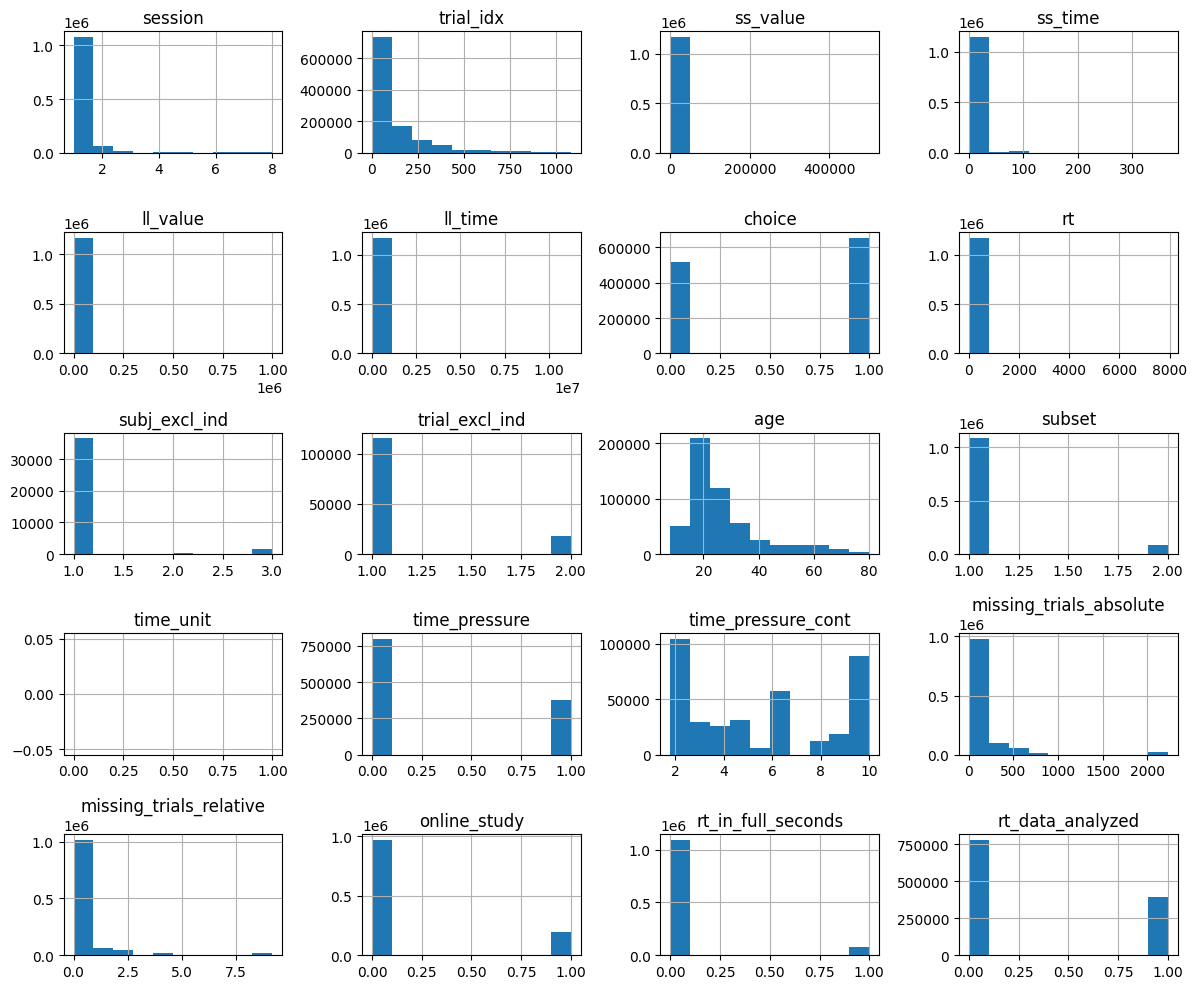

In [35]:
# --- distribution plot
import matplotlib.pyplot as plt
import numpy as np

# numeric columns
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

Key Insights:
Heavy Right Skew seen in ss_value, ll_value, ss_time, ll_time, rt (response time)

Most values are small, but few are extremely large.

Implication: Should use median and consider log transformation because

Binary Variables
Choice
Time_pressure
online_study
rt_data_analyzed

These are categorical features. Therefore Logistic Regression should be used as a baseline model.

Age Distribution
Slight right skew
most subjects are bwtween 20 - 40



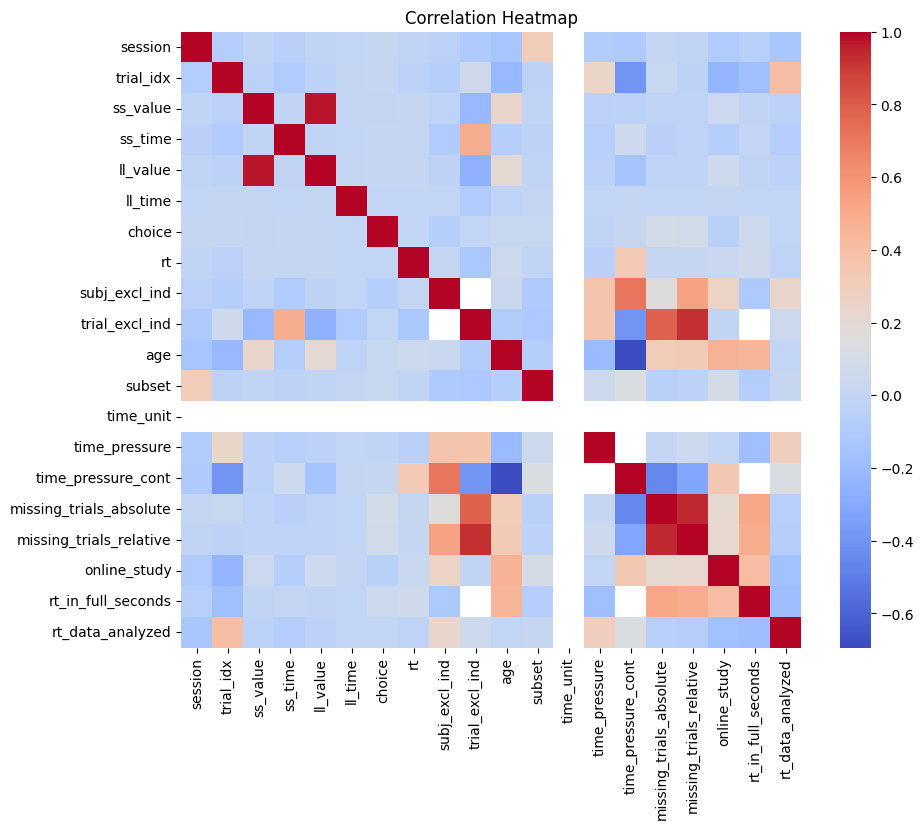

In [36]:
# --- correlation heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Key Insights:
Strong positive correlation between reward variables
ss_value and ll_value
Moderate correlation between ss_time and ll_time
Missing data variables are highly correelated missing_trials_absolute and missing_trials_reelative
Strong relationship between time_preessure and time_pressure_cont
Choice is VERY weakly correlated with most variables - this is a huge insight because behaviour is not linearnly explained so it suggests the need for logistic regression
